In [1]:
from cryosim import crowding
import torch
from cryosim.pdb2mrc import PDB2MRC
from cryosim.plotting_tools import plot3d

import plotly.io as pio
import plotly.graph_objects as go

# Use a renderer that works in JupyterLab
pio.renderers.default = "notebook_connected"
# alternatives: "notebook", "iframe_connected", "jupyterlab" (needs extensions)

%load_ext autoreload
%autoreload 2

In [2]:
# fetch pdb file
# note: warnings are from biopython, can be ignored.
pdb_code = "2HBS"
pm = PDB2MRC(pdb_code)
pm.fetch_pdb(pdb_folder="../pdb-data/", assembly=1)

Assemblies available: 1, 2
2HBS: Fetching Biological Assembly 1
File already exists: ../pdb-data/2HBS-assembly1.cif, skip fetching.
Parsing ../pdb-data/2HBS-assembly1.cif.


Extracting atom coordinates and element: 4827it [00:00, 176770.73it/s]


In [3]:
pm.max_diameter

np.float64(70.2264987557542)

In [4]:
# Samples 3D scattering potential onto specified grid
n = 256  # number of pixels per axis
dx = 0.5  # angstrom, pixel size.
pm.build_particle(n=n, dx=dx)
V = pm.particle.detach().clone()

Building element FE: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:01<00:00,  4.79it/s]


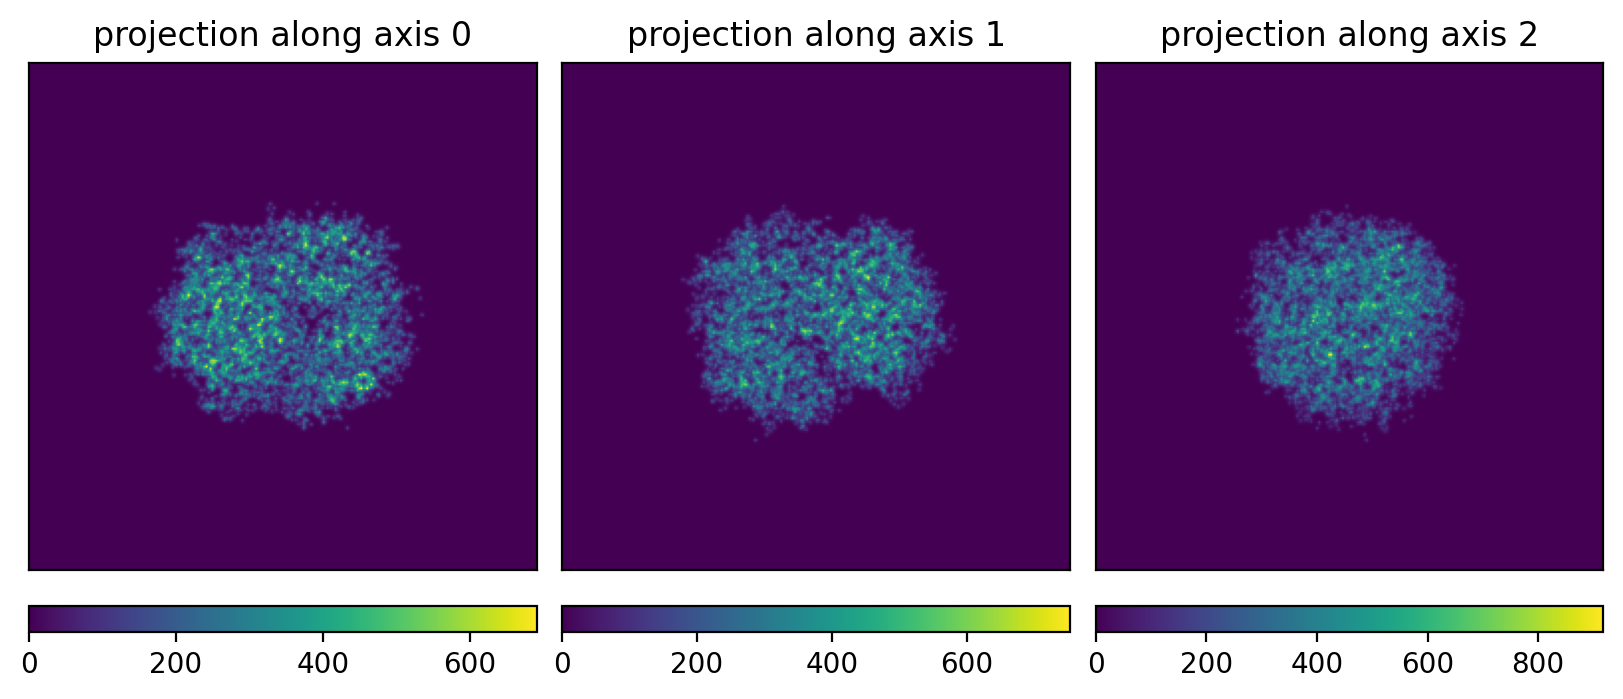

In [5]:
plot3d(V)

In [6]:
crowd, translations = crowding.crowd_with_duplicates(
    V, pm.max_diameter * 0.9, dx, return_coordinates=True
)

In [7]:
# Example coordinates: (N,3) tensor in (x,y,z) order
pts = translations  # replace with your points
r = pm.max_diameter / 2  # radius of each sphere


def plot_spheres(pts, r):
    """
    Create an interactive 3D scatter plot with spheres at each coordinate.
    """
    fig = go.Figure()

    # Create a unit sphere mesh (parametric)
    u = torch.linspace(0, 2 * torch.pi, 20)
    v = torch.linspace(0, torch.pi, 20)
    u_grid, v_grid = torch.meshgrid(u, v, indexing="ij")
    x_s = torch.cos(u_grid) * torch.sin(v_grid)
    y_s = torch.sin(u_grid) * torch.sin(v_grid)
    z_s = torch.cos(v_grid)

    # Add a sphere at each point
    for i in range(pts.shape[0]):
        x0, y0, z0 = pts[i]
        fig.add_trace(
            go.Surface(
                x=r * x_s + x0,
                y=r * y_s + y0,
                z=r * z_s + z0,
                opacity=0.6,
                showscale=False,
                colorscale="Viridis",
                lighting=dict(ambient=0.5, diffuse=0.7),
            )
        )

    fig.update_layout(
        scene=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Z",
            aspectmode="data",
            xaxis=dict(range=[-n * dx / 2, n * dx / 2], title="X"),
            yaxis=dict(range=[-n * dx / 2, n * dx / 2], title="Y"),
            zaxis=dict(range=[-n * dx / 2, n * dx / 2], title="Z"),
        ),
        width=800,
        height=800,
        showlegend=False,
    )

    fig.show()


plot_spheres(pts, r)